# 🎮 **Deep Q-Network (DQN) cho bài toán Tetris**

**Mô tả đề tài:** Áp dụng thuật toán Deep Q-Network (DQN) để huấn luyện agent tự động chơi Tetris.  Thay vì dùng Q-table, ta dùng một mạng neural để xấp xỉ  hàm action-value $\hat{q}(\mathbf{x}, u, \mathbf{w}) \approx q^*(x, u)$, kết hợp Experience Replay và Target Network để ổn định quá trình học.

In [1]:
!pip install gymnasium torch matplotlib numpy --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
SAVE_DIR = '/content/drive/MyDrive/Reinforcement Learning/Final Project/weights'
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import Image, display, HTML

##**Section 1 - Giới thiệu bài toán**

**1.1. Bài toán Teris**

Tetris là trò chơi xếp hình: các khối (piece) rơi từ trên xuống, người chơi xoay và di chuyển để xếp chúng thành hàng ngang đầy đủ - khi đó hàng đó bị xóa và ghi điểm. Game kết thúc khi các block chồng lên đến đỉnh.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/9c/Typical_Tetris_Game.svg/1280px-Typical_Tetris_Game.svg.png" width="180" align="right">

Trong RL, một Agent (tác nhân) tương tác với Environment (môi trường) theo vòng lặp:
- Agent **quan sát** trạng thái hiện tại của bàn cờ
- Agent **chọn hành động** (đặt block ở đâu, xoay thế nào)
- Environment trả về **phần thưởng** (reward) và trạng thái mới

**1.2 Mô tả môi trường**

Môi trường Tetris trong project này có các đặc điểm sau:

- **Episodic** -  mỗi *episode* là 1 ván chơi từ đầu đến khi thua (game over). Các ván độc lập nhau, agent reset về trạng thái ban đầu sau mỗi ván.

- **Fully observable** - agent thấy toàn bộ bàn cờ 20×10 tại mỗi bước, không có thông tin ẩn.

- **Stochastic** - piece tiếp theo xuất hiện ngẫu nhiên (1 trong 7 loại I/J/L/O/S/T/Z), agent không biết trước. Đây là nguồn ngẫu nhiên duy nhất trong môi trường.

**1.3 Định nghĩa State, Action, Reward**

**State $x_k$** - vector 4 features trích xuất từ bàn cờ sau khi đặt piece:

1. **lines_cleared** - Số dòng vừa xóa được - Mục tiêu chính của game
2. **holes** - Số ô trống bị che bởi block phía trên - Càng nhiều lỗ → càng khó xóa line sau
3. **bumpiness** - Tổng $\|h_i - h_{i+1}\|$ giữa các cột - Bề mặt lởm chởm → khó đặt piece tiếp
4. **total_height** - Tổng chiều cao tất cả cột - Càng cao → càng gần game over

```python
state = [lines_cleared, holes, bumpiness, total_height]
```

---

**Action $u_k$** - Grouped Action → Reward nhận ngay sau mỗi piece:
```python
action = (x_pos, rotation)
# x_pos   : cột đặt piece (0 → 9)
# rotation: góc xoay      (0 → 3)
```

---

**Reward $r_{k+1}$** - implement và so sánh 2 hàm reward:

**a. Reward 1 - Game Score**:

$$r_{k+1} = 1 + \text{lines}^2 \times 10 - 2 \cdot \mathbb{1}[\text{game over}]$$

1. **Survival bonus**: $+1$ → thưởng mỗi bước sống sót
2. **Lines reward**: $+\text{lines}^2 \times 10$ → lũy thừa khuyến khích xóa nhiều line cùng lúc
3. **Game-over penalty**: $-2$ → phạt khi thua

**b. Reward 2 - Heuristic Function**:

$$r_{k+1} = \Delta f, \quad \text{với } f = -0.51 \cdot H + 0.76 \cdot L - 0.36 \cdot O - 0.18 \cdot B$$

| Ký hiệu | Ý nghĩa |
|---------|---------|
| $H$ | Tổng chiều cao tất cả cột |
| $L$ | Số line đã xóa |
| $O$ | Số holes (ô trống bị che) |
| $B$ | Bumpiness — độ lởm chởm bề mặt |

Reward = thay đổi $\Delta f$ sau mỗi bước → mượt hơn, agent nhận tín hiệu học sau mỗi piece thay vì chỉ khi xóa line.

***Ref:** Yiyuan (2013). Tetris AI - The (Near) Perfect Bot.*
[Blog](https://codemyroad.wordpress.com/2013/04/14/tetris-ai-the-near-perfect-player/)

##**Section 2 - Deep Q-Network (DQN)**

**2.1. Vấn đề của Q-table?**

Cập nhật action-value trong Q-Learning:

$$\hat{q}(x_k, u_k) \leftarrow \hat{q}(x_k, u_k) + \alpha \left[ r_{k+1} + \gamma \max_u \hat{q}(x_{k+1}, u) - \hat{q}(x_k, u_k) \right]$$

Phương pháp Q-learning cổ điển lưu một bảng $Q(x, u)$ cho mọi cặp (trạng thái, hành động):

| Trạng thái | Action 1 | Action 2 | ... |
|-----------|---------|---------|-----|
| $x_1$ | 0.5 | 1.2 | ... |
| $x_2$ | -0.3 | 0.8 | ... |
| ... | ... | ... | ... |

**Vấn đề:** Bàn cờ Tetris có 20×10 = 200 ô, mỗi ô có thể trống hoặc có block → $2^{200} \approx 10^{60}$ trạng thái có thể.

**2.2. Giải pháp: Function Approximation**

Thay vì lưu bảng, ta dùng một hàm xấp xỉ $\hat{q}(x, u, \mathbf{w})$ để *ước lượng* giá trị Q:

$$\hat{q}(x, u, \mathbf{w}) \approx q^*(x, u)$$

Trong đó $\mathbf{w}$ là vector tham số (weights) - thay vì lưu $10^{60}$ giá trị, ta chỉ cần lưu các tham số của neural network

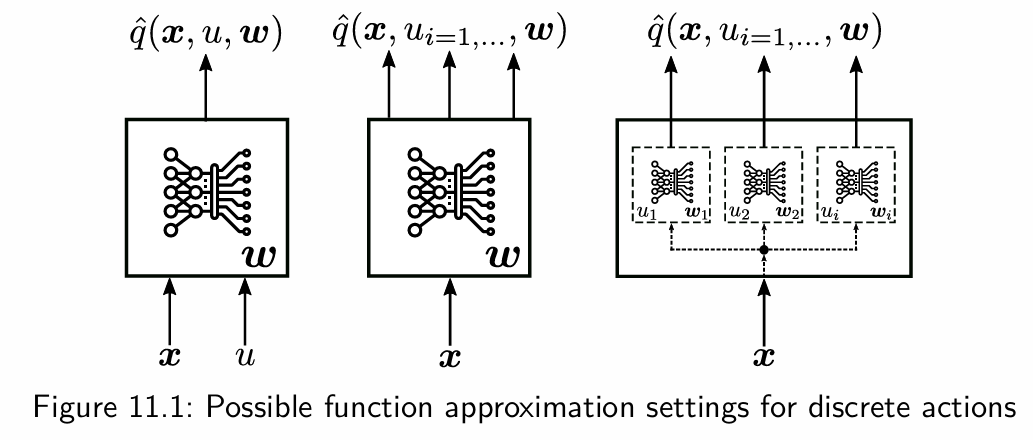

**2.3. Hàm mất mát và Q-target**

Huấn luyện network bằng cách minimize hàm loss:

$$\mathcal{L}(\mathbf{w}) = \left[ y_i - \hat{q}(x_i, u_i, \mathbf{w}) \right]^2_{\mathcal{D}_b}$$

Với Q-target $y_i$ tính từ target network $\mathbf{w}^-$:

$$y_i = \begin{cases}
r_{i+1} & \text{nếu } x_{i+1} \text{ là terminal (game over)} \\
r_{i+1} + \gamma \max_{u'} \hat{q}(x_{i+1}, u', \mathbf{w}^-) & \text{otherwise}
\end{cases}$$

## **Section 3: Teris Engine & Environment**

**3.1. Teris Engine**

In [5]:
TETROMINOES = {
    'I': [[1,1,1,1]],
    'J': [[1,0,0],[1,1,1]],
    'L': [[0,0,1],[1,1,1]],
    'O': [[1,1],[1,1]],
    'S': [[0,1,1],[1,1,0]],
    'T': [[0,1,0],[1,1,1]],
    'Z': [[1,1,0],[0,1,1]]
}

In [6]:
class Piece:
    """Đại diện cho 1 khối Tetris đang rơi."""
    def __init__(self, shape_name):
        self.name = shape_name
        color_map = {'I':1,'J':2,'L':3,'O':4,'S':5,'T':6,'Z':7}
        self.color_id = color_map[shape_name]
        base = np.array(TETROMINOES[shape_name], dtype=np.int8) * self.color_id
        all_rot = [base]
        for _ in range(3):
            all_rot.append(np.rot90(all_rot[-1], k=-1))
        self.shapes = []
        for s in all_rot:
            if not any(np.array_equal(s, u) for u in self.shapes):
                self.shapes.append(s)
        self.rotation = 0
        self.x = 0
        self.y = 0

    @property
    def current_shape(self):
        return self.shapes[self.rotation % len(self.shapes)]

    def copy(self):
        p = Piece(self.name)
        p.rotation = self.rotation
        p.x, p.y = self.x, self.y
        p.shapes = self.shapes
        return p

In [7]:
class TetrisEngine:
    """Lõi game Tetris 10×20. Không render, chỉ là logic thuần túy."""
    def __init__(self, width=10, height=20):
        self.width  = width
        self.height = height
        self.reset()

    def reset(self):
        self.board     = np.zeros((self.height, self.width), dtype=np.int8)
        self.game_over = False
        self._spawn_piece()

    def _spawn_piece(self):
        name = np.random.choice(list(TETROMINOES.keys()))
        self.current_piece = Piece(name)
        self.current_piece.x = self.width // 2 - self.current_piece.current_shape.shape[1] // 2
        self.current_piece.y = 0
        if self._check_collision(self.current_piece, 0, 0):
            self.game_over = True

    def _check_collision(self, piece, dx=0, dy=0):
        shape = piece.shapes[piece.rotation]
        for i, row in enumerate(shape):
            for j, cell in enumerate(row):
                if cell != 0:
                    bx = piece.x + j + dx
                    by = piece.y + i + dy
                    if bx < 0 or bx >= self.width or by >= self.height:
                        return True
                    if by >= 0 and self.board[by, bx] != 0:
                        return True
        return False

    def _lock_piece(self):
      shape = self.current_piece.shapes[self.current_piece.rotation]
      for i, row in enumerate(shape):
          for j, cell in enumerate(row):
              if cell != 0 and self.current_piece.y + i >= 0:
                  by = self.current_piece.y + i
                  bx = self.current_piece.x + j
                  if by < self.height and bx < self.width:
                      self.board[by, bx] = cell

    def _clear_lines(self):
        full = np.all(self.board != 0, axis=1)
        n = int(np.sum(full))
        if n > 0:
            self.board = self.board[~full]
            self.board = np.vstack([
                np.zeros((n, self.width), dtype=np.int8),
                self.board
            ])
            self._spawn_piece()
        return n

    def _check_game_over(self):
        return self.game_over

**3.2. Teris Environment**

In [8]:
class TetrisEnv(gym.Env):
    """
    STATE  (x_k) : [lines_cleared, holes, bumpiness, total_height]
    REWARD (r_k+1):
        Reward 1 — Game Score  : 1 + lines²×10 − 2·gameover
        Reward 2 — Heuristic   : Δf, f = −0.51H + 0.76L − 0.36O − 0.18B
    """
    def __init__(self, reward_type='game_score'):
        super().__init__()
        self.engine      = TetrisEngine()
        self.reward_type = reward_type      # game_score | heuristic
        self._prev_f     = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.engine.reset()
        stats          = self._get_heuristic_stats()
        self._prev_f   = self._heuristic_f(0, stats)
        state          = [0, stats['holes'], stats['bumpiness'], stats['height']]
        return state, stats

    # Group Action - chọn vị trí đặt piece cuối (x_pos, rotation)
    def step(self, action):
        """Grouped action: action = (x_pos, rotation)"""
        x_pos, rotation = action
        self.engine.current_piece.rotation = rotation
        self.engine.current_piece.x        = x_pos

        # Hard drop — thả thẳng xuống đáy
        while not self.engine._check_collision(self.engine.current_piece, 0, 1):
            self.engine.current_piece.y += 1
        self.engine._lock_piece()

        lines  = self.engine._clear_lines()
        stats  = self._get_heuristic_stats()
        reward = self._calculate_reward(lines, stats)
        self.engine.game_over = self.engine._check_game_over()
        state  = [lines, stats['holes'], stats['bumpiness'], stats['height']]
        return state, reward, self.engine.game_over, False, stats

    def get_possible_states(self):
        """
        Trả về dict: {(x_pos, rotation): [4 features]}
        Agent dùng dict này để chọn action tốt nhất (grouped action)
        """
        possible    = {}
        orig_board  = self.engine.board.copy()
        orig_piece  = self.engine.current_piece.copy()

        for rotation in range(len(orig_piece.shapes)):
            for x in range(self.engine.width):
                self.engine.current_piece         = orig_piece.copy()
                self.engine.current_piece.rotation = rotation
                self.engine.current_piece.x        = x
                self.engine.current_piece.y        = 0

                if self.engine._check_collision(self.engine.current_piece, 0, 0):
                    continue

                while not self.engine._check_collision(self.engine.current_piece, 0, 1):
                    self.engine.current_piece.y += 1
                self.engine._lock_piece()
                lines = self.engine._clear_lines()
                stats = self._get_heuristic_stats()
                possible[(x, rotation)] = [
                    lines, stats['holes'], stats['bumpiness'], stats['height']
                ]
                self.engine.board        = orig_board.copy()
                self.engine.current_piece = orig_piece

        return possible

    # Reward Function
    def _calculate_reward(self, lines, stats):
        if self.reward_type == 'heuristic':
            # r = Δf, f = −0.51H + 0.76L − 0.36O − 0.18B
            f_new       = self._heuristic_f(lines, stats)
            reward      = f_new - self._prev_f
            self._prev_f = f_new
            if self.engine.game_over:
                reward -= 2.0
        else:
            reward = 1.0 + (lines ** 2) * 10
            if self.engine.game_over:
                reward -= 2.0
        return float(reward)

    def _heuristic_f(self, lines, stats):
        """f = −0.51·H + 0.76·L − 0.36·O − 0.18·B"""
        return (-0.51 * stats['height']
                + 0.76 * lines
                - 0.36 * stats['holes']
                - 0.18 * stats['bumpiness'])

    # Feature Extraction
    def _get_heuristic_stats(self):
        """Trích xuất 4 features từ board hiện tại."""
        board = self.engine.board

        # Holes: ô trống nằm dưới ô đã lấp
        holes = 0
        for col in board.T:
            indices = np.where(col != 0)[0]
            if len(indices) > 0:
                holes += int(np.sum(col[indices[0]:] == 0))

        # Height của từng cột
        mask     = board != 0
        inv_h    = np.where(mask.any(axis=0), np.argmax(mask, axis=0), 20)
        heights  = 20 - inv_h
        total_h  = int(np.sum(heights))

        # Bumpiness: tổng |h[i] − h[i+1]|
        bumpiness = int(np.sum(np.abs(np.diff(heights))))

        return {'holes': holes, 'bumpiness': bumpiness, 'height': total_h}

    def _check_game_over(self):
        return self.engine.game_over

## **Section 4: Deep Q-Network**

**4.1. Deep Q-Network cho Group Action**

In [9]:
class DeepQNetwork(nn.Module):
    """
    Xấp xỉ hàm q̂(x, u, w)
    Input : 4 features [lines, holes, bumpiness, height]
    Output: 1 Q-value scalar
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.net(x)

In [10]:
dummy = torch.zeros(5, 4)   # batch 5 states, mỗi state 4 features

grouped = DeepQNetwork()

out_g = grouped(dummy)

print("\n=== DeepQNetwork (Grouped) ===")
print(f"Input shape  : {dummy.shape}  → (batch=5, features=4)")
print(f"Output shape : {out_g.shape}  → (batch=5, Q_value=1)")
print(f"Tổng params  : {sum(p.numel() for p in grouped.parameters()):,}")


=== DeepQNetwork (Grouped) ===
Input shape  : torch.Size([5, 4])  → (batch=5, features=4)
Output shape : torch.Size([5, 1])  → (batch=5, Q_value=1)
Tổng params  : 4,545


**4.2. ReplayMemory**

In [11]:
class ReplayMemory:
    """
    Lưu tuple: (state, next_state, reward, done)
    """
    def __init__(self, capacity=30_000):
        self.memory = deque(maxlen=capacity)

    def push(self, state, next_state, reward, done):
        self.memory.append((state, next_state, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

    def is_ready(self, batch_size):
        """Chỉ train khi có đủ samples"""
        return len(self.memory) >= batch_size

**4.3. Hyperparameters**

In [12]:
CONFIG = {
    # Network
    'learning_rate'     : 0.001,

    # RL core
    'gamma'             : 0.99,

    # Replay Buffer
    'replay_capacity'   : 30_000,
    'batch_size'        : 512,

    # Exploration (ε-greedy)
    'epsilon_start'     : 1.0,
    'epsilon_end'       : 0.001,
    'num_decay_epochs'  : 2_000,

    # Target Network
    'target_update_freq': 500,        # episodes

    # Training
    'num_episodes'      : 3_000,
    'save_interval'     : 500,
    'save_path'         : SAVE_DIR + '/dqn_tetris.pth',
}

CONFIG['epsilon_step'] = (
    (CONFIG['epsilon_start'] - CONFIG['epsilon_end'])
    / CONFIG['num_decay_epochs']
)

for k, v in CONFIG.items():
    print(f"- {k:25s} = {v}")

- learning_rate             = 0.001
- gamma                     = 0.99
- replay_capacity           = 30000
- batch_size                = 512
- epsilon_start             = 1.0
- epsilon_end               = 0.001
- num_decay_epochs          = 2000
- target_update_freq        = 500
- num_episodes              = 3000
- save_interval             = 500
- save_path                 = /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris.pth
- epsilon_step              = 0.0004995


**4.4. DQN Agent**

In [13]:
class DQNAgent:
    """
    action_type: 'grouped' | 'single'
        - grouped : policy_net output 1 scalar, act() nhận dict
        - single  : policy_net output 4 values, act() nhận state
    """
    def __init__(self, config, action_type='grouped', device='cpu'):
        self.device      = device
        self.action_type = action_type

        # Hyperparameters
        self.gamma        = config['gamma']
        self.batch_size   = config['batch_size']
        self.epsilon      = config['epsilon_start']
        self.epsilon_min  = config['epsilon_end']
        self.epsilon_step = config['epsilon_step']

        # Networks: policy (w) và target (w⁻)
        if action_type == 'grouped':
            self.policy_net = DeepQNetwork().to(device)
            self.target_net = DeepQNetwork().to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer & Loss
        self.optimizer = optim.Adam(
            self.policy_net.parameters(),
            lr=config['learning_rate']
        )
        self.loss_fn = nn.MSELoss()

        # Replay Buffer
        self.memory = ReplayMemory(config['replay_capacity'])

    # ACT Grouped: nhận dict {(x,rot): features}
    def act(self, next_states_dict):
        """
        Epsilon-greedy cho GROUPED action
        next_states_dict: {(x,rot): [4 features]} từ get_possible_states()
        """
        actions  = list(next_states_dict.keys())
        features = list(next_states_dict.values())
        if not actions:
            return None, None

        if random.random() <= self.epsilon:
            # EXPLORATION: chọn ngẫu nhiên
            idx = random.randrange(len(actions))
            return actions[idx], features[idx]

        # EXPLOITATION: feed tất cả features vào policy_net 1 lần
        feat_tensor = torch.FloatTensor(
            np.array(features)
        ).to(self.device)

        with torch.no_grad():
            q_values = self.policy_net(feat_tensor)   # shape (N, 1)

        best_idx = torch.argmax(q_values).item()
        return actions[best_idx], features[best_idx]

    # REPLAY - core learning step
    def replay(self):
        """
        1. Sample mini-batch Db từ D
        2. Tính Q-target: yi = r + γ·max Q̂(x', w⁻)·(1−done)
        3. Tính loss: L(w) = [yi − Q̂(x, w)]²_Db
        4. Backprop + optimizer step
        """
        if not self.memory.is_ready(self.batch_size):
            return 0.0

        batch = self.memory.sample(self.batch_size)
        states, next_states, rewards, dones = zip(*batch)

        states      = torch.FloatTensor(np.array(states)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        rewards     = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        dones       = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Q-target dùng target_net w⁻
        with torch.no_grad():
            next_q = self.target_net(next_states)   # shape (batch, 1) hoặc (batch, 4)

        # yi = r + γ·Q̂(x', w⁻)·(1−done)
        target_q = rewards + self.gamma * next_q * (1 - dones)

        # Prediction từ policy_net w
        current_q = self.policy_net(states)

        # Loss: L(w) = [yi − Q̂(x,w)]²_Db
        loss = self.loss_fn(current_q, target_q)

        # Gradient descent
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            self.policy_net.parameters(), max_norm=1.0
        )
        self.optimizer.step()
        return loss.item()

    def update_target_network(self):
        """w⁻ ← w (hard update mỗi target_update_freq episodes)"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        """Giảm ε tuyến tính sau mỗi episode"""
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_step)

    def save(self, path):
        torch.save(self.policy_net.state_dict(), path)
        print(f"Model saved → {path}")

    def load(self, path):
        self.policy_net.load_state_dict(
            torch.load(path, map_location=self.device)
        )
        self.update_target_network()
        print(f"Model loaded ← {path}")

## **Section 5: Training Loop**

In [14]:
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Thiết bị đang dùng: {DEVICE}")

✅ Thiết bị đang dùng: cpu


In [15]:
def train_one(action_type, reward_type, config=CONFIG, device=DEVICE):
    """
    action_type : 'grouped' | 'single'
    reward_type : 'game_score' | 'heuristic'
    """
    env   = TetrisEnv(reward_type=reward_type)
    agent = DQNAgent(config, action_type=action_type, device=device)

    history = {
        'episode'       : [],
        'total_reward'  : [],
        'lines_cleared' : [],
        'epsilon'       : [],
        'loss'          : [],
        'pieces_placed' : [],
    }

    best_reward = -float('inf')
    save_path   = config['save_path'].replace(
        '.pth', f'_{action_type}_{reward_type}.pth'
    )
    t_start = time.time()

    label = f"{action_type.upper()} + {reward_type.upper()}"
    print(f"\n{'='*55}")
    print(f"🚀 Bắt đầu train: {label}")
    print(f"   Episodes : {config['num_episodes']}")
    print(f"   Device   : {device}")
    print(f"{'='*55}")

    for episode in range(1, config['num_episodes'] + 1):

        state, _ = env.reset()
        total_reward  = 0.0
        total_lines   = 0
        total_loss    = 0.0
        loss_count    = 0
        pieces_placed = 0

        # Episode loop
        while True:

            # === GROUPED ===
            if action_type == 'grouped':
                next_states_dict = env.get_possible_states()
                if not next_states_dict:
                    break
                action, next_state = agent.act(next_states_dict)
                if action is None:
                    break
                new_state, reward, done, _, _ = env.step(action)
                agent.memory.push(next_state, new_state, reward, done)

            # Learn
            loss = agent.replay()
            if loss > 0:
                total_loss += loss
                loss_count += 1

            state         = new_state
            total_reward += reward
            total_lines  += new_state[0]   # lines_cleared trong step này
            pieces_placed += 1

            if done:
                break

        # Sau mỗi episode
        if episode % config['target_update_freq'] == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        avg_loss = total_loss / loss_count if loss_count > 0 else 0.0

        history['episode'].append(episode)
        history['total_reward'].append(total_reward)
        history['lines_cleared'].append(total_lines)
        history['epsilon'].append(agent.epsilon)
        history['loss'].append(avg_loss)
        history['pieces_placed'].append(pieces_placed)

        # Save best model
        if total_reward > best_reward:
            best_reward = total_reward
            agent.save(save_path)

        # Checkpoint
        if episode % config['save_interval'] == 0:
            ckpt = save_path.replace('.pth', f'_ep{episode}.pth')
            agent.save(ckpt)

        # Log mỗi 100 episodes
        if episode % 100 == 0:
            r   = slice(-100, None)
            avg_r    = np.mean(history['total_reward'][r])
            avg_l    = np.mean(history['lines_cleared'][r])
            avg_loss_r = np.mean(history['loss'][r])
            elapsed  = (time.time() - t_start) / 60
            print(f"Ep {episode:>5d}/{config['num_episodes']} │ "
                  f"Avg Reward: {avg_r:>8.1f} │ "
                  f"Avg Lines: {avg_l:>5.2f} │ "
                  f"ε: {agent.epsilon:.4f} │ "
                  f"Loss: {avg_loss_r:.4f} │ "
                  f"⏱ {elapsed:.1f}min")

    print(f"   Best reward : {best_reward:.1f}")
    print(f"   Model saved : {save_path}")
    return history

all_results = {}

In [16]:
import pickle

def save_history(history, key):
    """Lưu history sau khi train xong 1 experiment"""
    path = SAVE_DIR + f'/history_{key}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(history, f)
    print(f"History saved → {path}")

def load_all_history():
    """Load tất cả history đã train được"""
    all_results = {}
    for key in ['grouped_heuristic', 'grouped_game_score']:
        path = SAVE_DIR + f'/history_{key}.pkl'
        if os.path.exists(path):
            with open(path, 'rb') as f:
                all_results[key] = pickle.load(f)
            print(f"Loaded: {key}")
        else:
            print(f"Chưa có: {key}")
    return all_results

In [18]:
all_results['grouped_game_score'] = train_one('grouped', 'game_score')
save_history(all_results['grouped_game_score'], 'grouped_game_score')


🚀 Bắt đầu train: GROUPED + GAME_SCORE
   Episodes : 3000
   Device   : cuda
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_game_score.pth
Ep   100/3000 │ Avg Reward:     36.8 │ Avg Lines:  0.53 │ ε: 0.9501 │ Loss: 5.1639 │ ⏱ 0.5min
Model saved → /co

In [17]:
all_results['grouped_heuristic'] = train_one('grouped', 'heuristic')
save_history(all_results['grouped_heuristic'], 'grouped_heuristic')


🚀 Bắt đầu train: GROUPED + HEURISTIC
   Episodes : 3000
   Device   : cpu
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Ep   100/3000 │ Avg Reward:   -128.8 │ Avg Lines:  0.48 │ ε: 0.9501 │ Loss: 7.5640 │ ⏱ 0.6min
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Ep   200/3000 │ Avg Reward:   -128.7 │ Avg Lines:  0.50 │ ε: 0.9001 │ Loss: 8.8638 │ ⏱ 1.1min
Model saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_tetris_grouped_heuristic.pth
Model saved → /content/drive/MyDrive/Reinforcem

Loaded: grouped_heuristic
Loaded: grouped_game_score


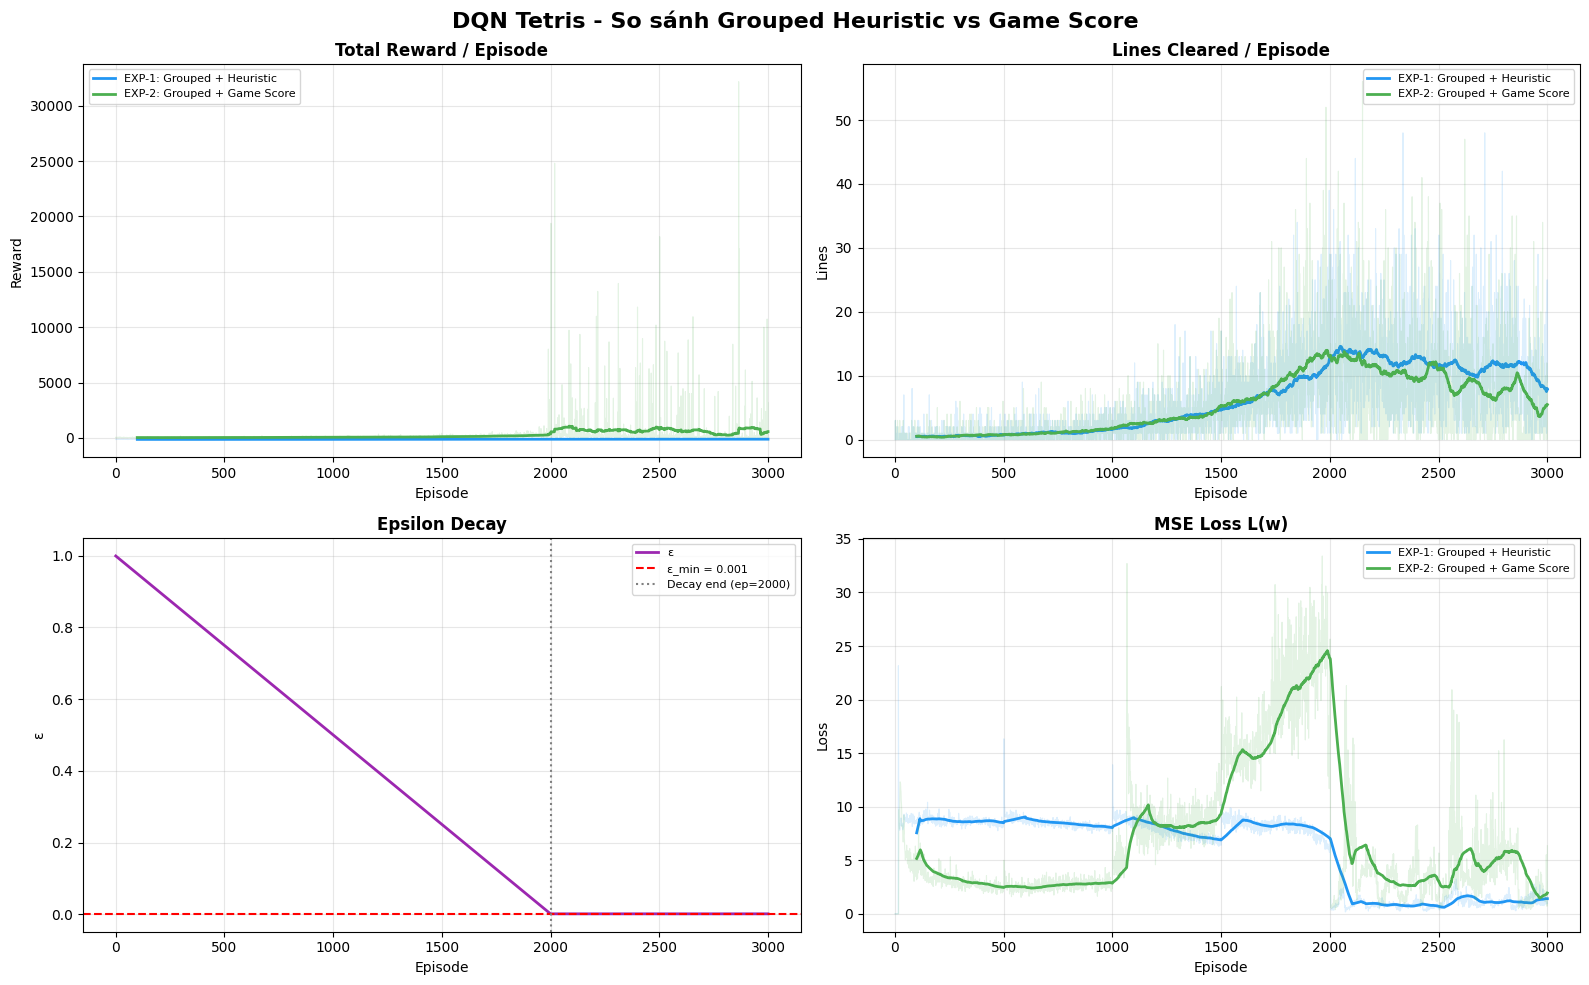

Plot saved → /content/drive/MyDrive/Reinforcement Learning/Final Project/weights/dqn_comparison.png


In [18]:
import matplotlib.pyplot as plt

def plot_all_results(all_results, window=100):

    LABELS = {
        'grouped_heuristic' : 'EXP-1: Grouped + Heuristic',
        'grouped_game_score': 'EXP-2: Grouped + Game Score',
    }
    COLORS = {
        'grouped_heuristic' : '#2196F3',
        'grouped_game_score': '#4CAF50',
    }
    YLABELS = {
        'total_reward' : 'Reward',
        'lines_cleared': 'Lines',
        'loss'         : 'Loss',
    }

    def moving_avg(data, w):
        if len(data) < w:
            return None, None
        ma = np.convolve(data, np.ones(w)/w, mode='valid')
        return list(range(w, len(data)+1)), ma

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        'DQN Tetris - So sánh Grouped Heuristic vs Game Score',
        fontsize=16, fontweight='bold'
    )

    metrics = [
        ('total_reward',  'Total Reward / Episode',  axes[0, 0]),
        ('lines_cleared', 'Lines Cleared / Episode', axes[0, 1]),
        ('loss',          'MSE Loss L(w)',            axes[1, 1]),
    ]

    for metric, title, ax in metrics:
        for key, history in all_results.items():
            if key not in LABELS:   # bỏ qua single nếu có trong dict
                continue
            data     = history[metric]
            episodes = history['episode']
            color    = COLORS[key]
            label    = LABELS[key]

            ax.plot(episodes, data,
                    alpha=0.15, color=color, linewidth=0.8)

            x_ma, ma = moving_avg(data, window)
            if ma is not None:
                ax.plot(x_ma, ma,
                        color=color, linewidth=2, label=label)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Episode')
        ax.set_ylabel(YLABELS[metric])
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # Epsilon Decay
    ax_eps   = axes[1, 0]
    key0     = list(LABELS.keys())[0]
    eps_data = all_results[key0]['epsilon']
    eps_ep   = all_results[key0]['episode']

    ax_eps.plot(eps_ep, eps_data, color='#9C27B0', linewidth=2, label='ε')
    ax_eps.axhline(
        y=CONFIG['epsilon_end'], color='red', linestyle='--',
        label=f"ε_min = {CONFIG['epsilon_end']}"
    )
    ax_eps.axvline(
        x=CONFIG['num_decay_epochs'], color='gray', linestyle=':',
        label=f"Decay end (ep={CONFIG['num_decay_epochs']})"
    )
    ax_eps.set_title('Epsilon Decay', fontsize=12, fontweight='bold')
    ax_eps.set_xlabel('Episode')
    ax_eps.set_ylabel('ε')
    ax_eps.legend(fontsize=8)
    ax_eps.grid(alpha=0.3)

    plt.tight_layout()
    save_plot_path = SAVE_DIR + '/dqn_comparison.png'
    plt.savefig(save_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved → {save_plot_path}")


all_results = load_all_history()
plot_all_results(all_results)